# 주택 가격 데이터셋
* 미국 아이오와 주 에임스 지방의 주택 가격 정보를 가짐
* RMSLE 기반으로 성능 평가 수행 :가격 비싼 주택일수록 오류 미치는 비중 높아서 로그 변환 필
* 타깃 값은 마지막 칼럼인 SalePrice

In [41]:
### 실습 전체 라이브러리 임포트
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline
warnings.filterwarnings("ignore", category=RuntimeWarning)

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.stats import skew

# 데이터 사전 처리(preprocessing)
* 문자 데이터가 있음 -> 원핫인코딩 변환 : Null 값은 None 칼럼으로 대체하므로 별도의 널값 대체하는 로직 필요 없음
* Null값이 너무 많은 피처 있음
  * 삭제하거나
  * 평균값으로 대체

In [2]:
house_df_org = pd.read_csv('../kaggle/house_price/house_price.csv')
house_df = house_df_org.copy()

print('데이터 데트의 형상 : ', house_df.shape)
print('\n전체 피처의 타입 : \n', house_df.dtypes.value_counts())
isnull_series = house_df.isnull().sum()
print("\nNull 칼럼과 그 건수 : \n", isnull_series[isnull_series > 0].sort_values(ascending=False))

데이터 데트의 형상 :  (1460, 81)

전체 피처의 타입 : 
 object     43
int64      35
float64     3
dtype: int64

Null 칼럼과 그 건수 : 
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
MasVnrType         8
Electrical         1
dtype: int64


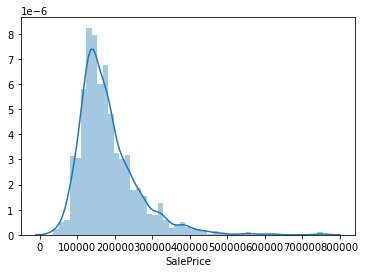

In [3]:
### 타깃값의 분포도가 정규 분포인지 확인

sns.distplot(house_df['SalePrice']) #왼쪽으로 치우쳐 정규 분포에서 벗어남

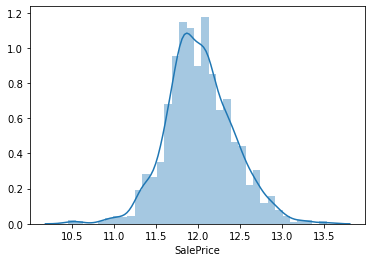

In [4]:
###로그 변환 적용하고 확인해보기
log_SalePrice = np.log1p(house_df['SalePrice'])
sns.distplot(log_SalePrice) #정규 분포로 변환됨

In [5]:
### 로그 변환
original_SalePrice = house_df['SalePrice']
house_df['SalePrice'] = np.log1p(house_df['SalePrice'])

### NULL 많거나 불필요한 칼럼 삭제, 평균값 대체
house_df.drop(['Id', 'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu'], axis=1, inplace=True)
house_df.fillna(house_df.mean(), inplace=True)

### 문자형 데이터 원핫인코딩
house_df_ohe = pd.get_dummies(house_df)

print('get_dummies 수행 후 데이터 형상 : ', house_df_ohe.shape) # 피처 수 증가
null_col_count = house_df_ohe.isnull().sum()[house_df_ohe.isnull().sum()>0]
print('*** NULL 피처의 Type : \n', house_df_ohe.dtypes[null_col_count.index])

get_dummies 수행 후 데이터 형상 :  (1460, 271)
*** NULL 피처의 Type : 
 Series([], dtype: object)


# 선형 회귀 모델 학습/예측/평가(1)
* 타깃값 SalePrice와 에측값 모두 로그 변환된 기반 -> 예측 결과 오류 대한 RMSE만 적용하면 바로 RMSLE 측정

In [6]:
### 모델 별 RMSE 측정할 함수 선언

def get_rmse(model):
    pred = model.predict(x_test)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    print(model.__class__.__name__, ' 로그 변환된 RMSE : ', np.round(rmse, 3))
    return rmse

def get_rmses(models):
    rmses = []
    for model in models:
        rmse = get_rmse(model)
        rmses.append(rmse)
    return rmses

In [7]:
y_target = house_df_ohe['SalePrice']
x_features = house_df_ohe.drop(['SalePrice'], axis=1, inplace=False)
x_train, x_test, y_train, y_test = train_test_split(x_features, y_target, test_size=0.2, random_state=156)

lr_reg = LinearRegression()
lr_reg.fit(x_train, y_train)
ridge_reg = Ridge()
ridge_reg.fit(x_train, y_train)
lasso_reg = Lasso()
lasso_reg.fit(x_train, y_train)

models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models) #라쏘 회귀는 회귀 성능이 다른 모델보다 떨어짐 -> 최적 하이퍼 파라미터 튜닝 필요해 보임

LinearRegression  로그 변환된 RMSE :  0.132
Ridge  로그 변환된 RMSE :  0.128
Lasso  로그 변환된 RMSE :  0.176


[0.13189576579154288, 0.1275084633405303, 0.17628250556471406]

# 피처별 회귀 계수 확인하는 함수 제작
* 어떤 피처의 회귀 계수로 구성되는지 확인
* 상위 및 하위 10개 추려보기

In [8]:
###상하위 10개씩 회귀 계수 반환

def get_top_bottom_coef(model, n=10):
    #coef_ 속성을 기반으로 시리즈 객체 생성
    coef = pd.Series(model.coef_, index=x_features.columns)
    #상하위 10개씩 회귀 계수 추출해 반환
    coef_high = coef.sort_values(ascending=False).head(n)
    coef_low = coef.sort_values(ascending=False).tail(n)
    return coef_high, coef_low

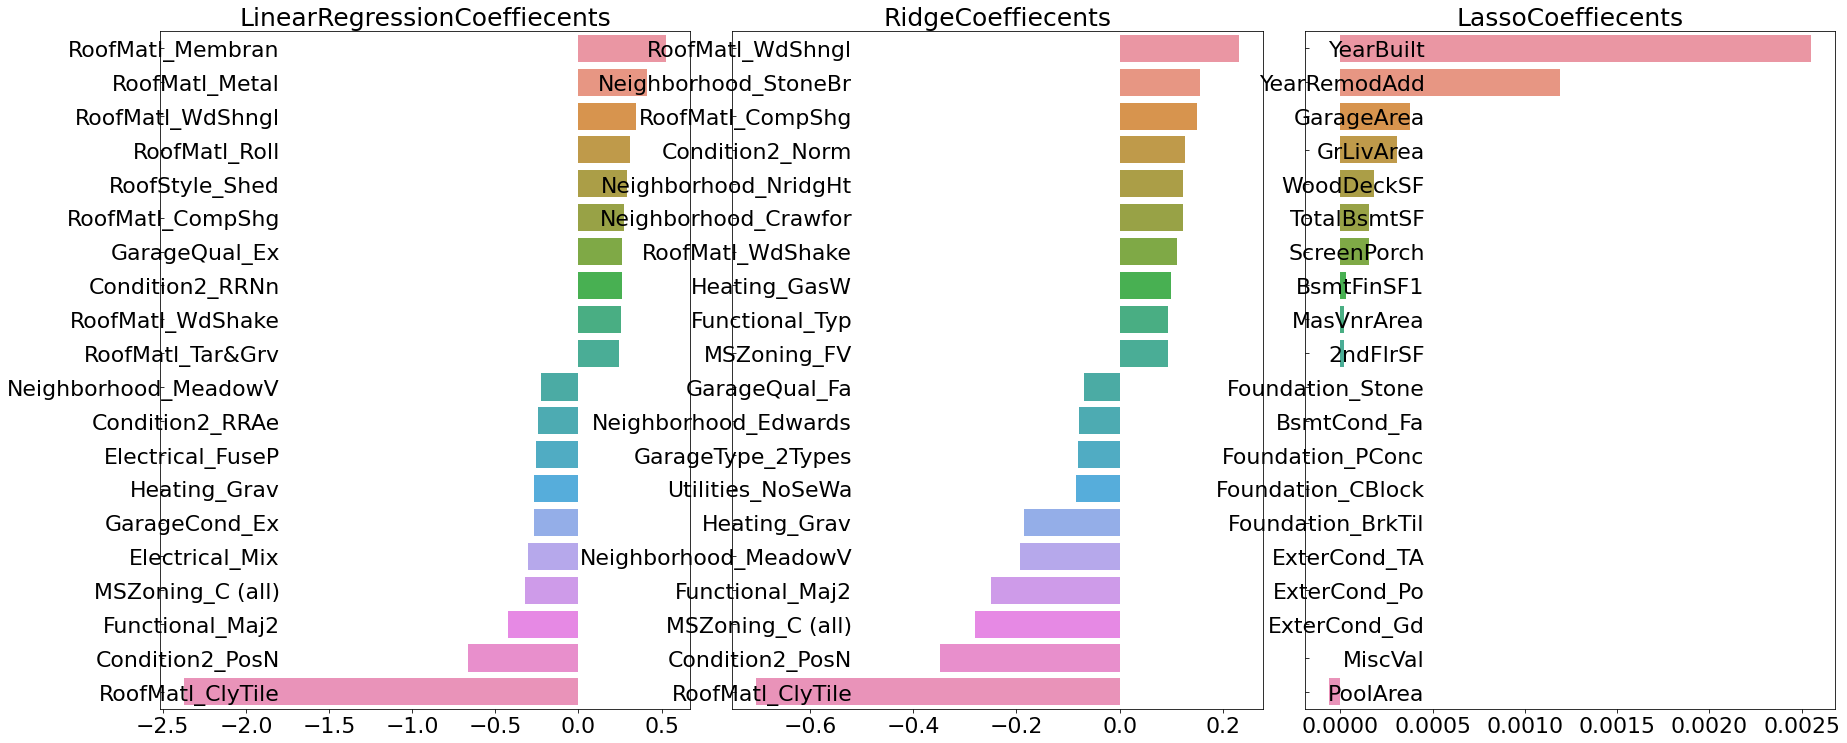

In [13]:
###회귀 계수 시각화

def visualize_coefficient(models):
    fig, axs = plt.subplots(figsize=(24, 10), nrows=1, ncols=3)
    fig.tight_layout()
    
    for i_num, model in enumerate(models):
        coef_high, coef_low = get_top_bottom_coef(model)
        coef_concat = pd.concat([coef_high, coef_low]) # 상하위 10개 회귀 계수 판다스 concat으로 결합
        
        axs[i_num].set_title(model.__class__.__name__ +'Coeffiecents', size=25)
        axs[i_num].tick_params(axis='y', direction='in', pad=-120)
        for label in (axs[i_num].get_xticklabels() + axs[i_num].get_yticklabels()):
            label.set_fontsize(22)
        sns.barplot(x=coef_concat.values, y=coef_concat.index, ax=axs[i_num])
        
models = [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)

* OLS 기반의 선형회귀와 릿지 회귀는 회귀 계수가 유사하나, 라쏘는 전체적으로 회귀 계수 값이 매우 작은 등 문제 있음
* 학습 데이터 분할에 문제가 있는지 확인하고자, 전체 데이터셋을 5개의 교차 검증 폴드로 분할해 평균 RMSE 측정

In [18]:
### 학습 데이터를 분할하지 않고 평가를 수행하는 함수

def get_avg_rmse_cv(models):
    for model in models:
        rmse_list = np.sqrt(-cross_val_score(model, x_features, y_target, scoring="neg_mean_squared_error", cv=5))
        rmse_avg = np.mean(rmse_list)
        print('\n{0} CV RMSE 값 리스트 : {1}'.format(model.__class__.__name__, np.round(rmse_list, 3)))
        print('{0} CV 평균 RMSE 값 : {1}'.format(model.__class__.__name__, np.round(rmse_avg, 3)))

In [19]:
### 각 모델의 CV RMSE 값 출력
models = [lr_reg, ridge_reg, lasso_reg]
get_avg_rmse_cv(models)


LinearRegression CV RMSE 값 리스트 : [0.135 0.165 0.168 0.111 0.198]
LinearRegression CV 평균 RMSE 값 : 0.155

Ridge CV RMSE 값 리스트 : [0.117 0.154 0.142 0.117 0.189]
Ridge CV 평균 RMSE 값 : 0.144

Lasso CV RMSE 값 리스트 : [0.161 0.204 0.177 0.181 0.265]
Lasso CV 평균 RMSE 값 : 0.198


* 5개의 폴드 세트로 학습한 뒤에도 여전히 라쏘가 성능 떨어짐
* 릿지와 라쏘 모델에 대해 알파 하이퍼 파라미터 변화시키며 최적값 도출해보자

In [20]:
### 최적화 하이퍼 파라미터 계산할 함수

def print_best_params(model, params):
    grid_model = GridSearchCV(model, param_grid=params, scoring='neg_mean_squared_error', cv=5)
    grid_model.fit(x_features, y_target)
    rmse = np.sqrt(-1*grid_model.best_score_)
    print('{0} 5CV 시 최적 평균 RMSE 값 : {1}, 최적 alpha : {2}'.format(model.__class__.__name__, np.round(rmse, 4), grid_model.best_params_))


In [21]:
ridge_params = {'alpha' : [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha' : [0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]}
print_best_params(ridge_reg, ridge_params)
print_best_params(lasso_reg, lasso_params)

Ridge 5CV 시 최적 평균 RMSE 값 : 0.1418, 최적 alpha : {'alpha': 12}
Lasso 5CV 시 최적 평균 RMSE 값 : 0.142, 최적 alpha : {'alpha': 0.001}


* 라쏘 모델이 alpha 값 최적화 이후 예측 성능이 많이 좋아짐 -> 이 값으로 학습 예측 평가 진행

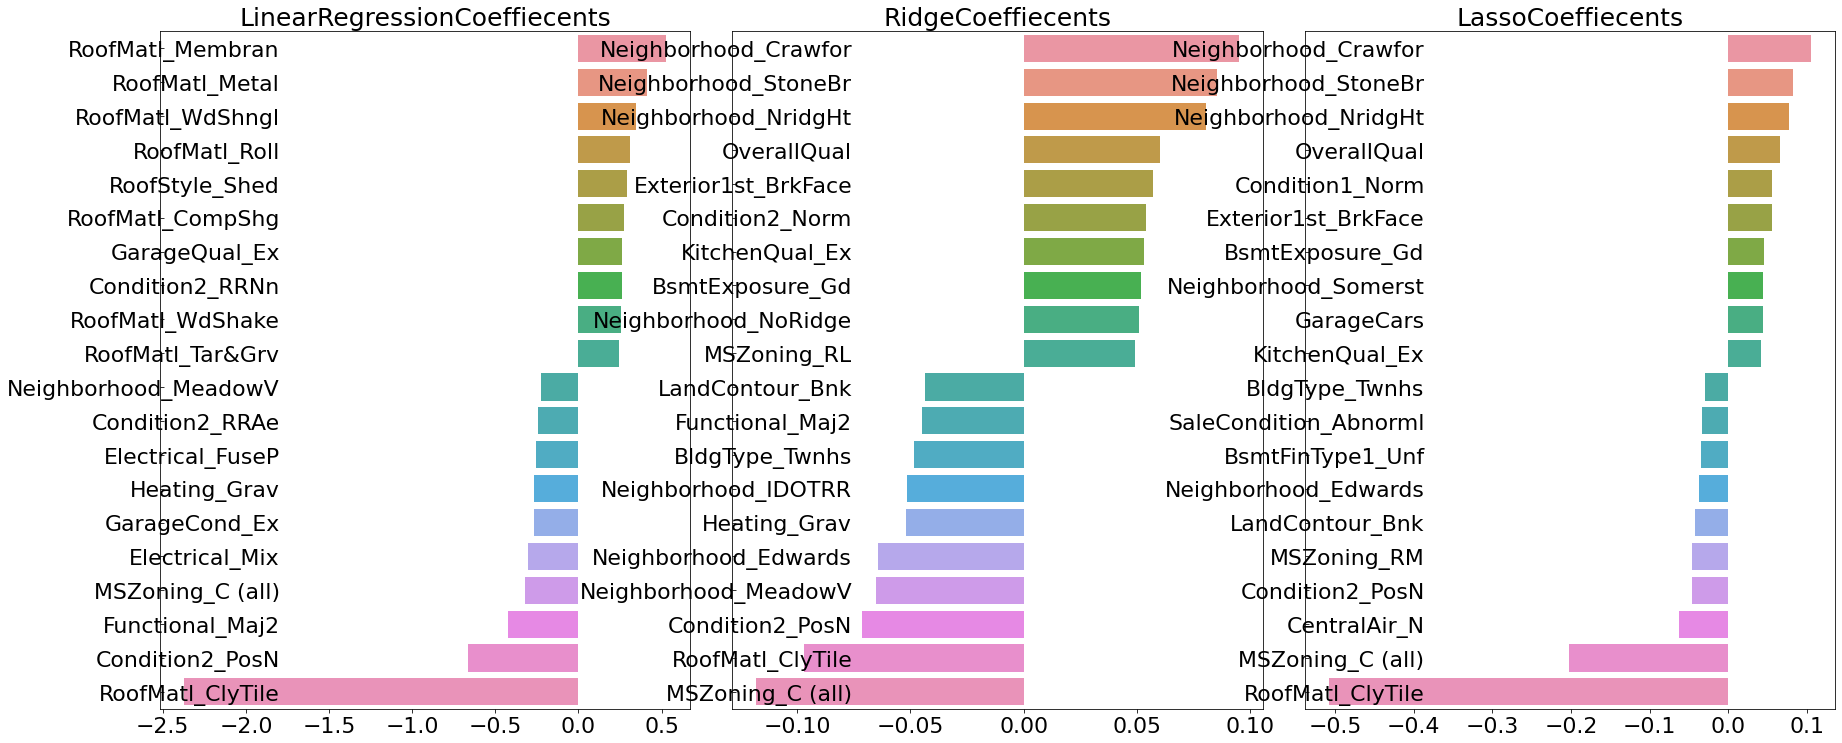

In [23]:
lr_reg = LinearRegression()
lr_reg.fit(x_train, y_train)
ridge_reg = Ridge(alpha=12)
ridge_reg.fit(x_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(x_train, y_train)

models = [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)

* 라쏘 모델이 릿지에 비해 동일한 피처라도 회귀 계수 값이 상당이 낮긴 하지만, 전보다는 많이 나아짐
* 데이터세트 추가적 가공으로 모델 튜닝을 더 진행해보자
  * 피처 데이터셋의 데이터 분포를 살펴보자
  * 이상치(outlier) 데이터 처리하자
* 피처 데이터셋의 데이터 분포
  * 모든 숫자형 피처의 데이터 분포도를 확인해 분포도가 어느 정도로 왜곡됐는지 알아보자
  * 사이파이 stats 모듈의 skew() 함수 이용 : 칼럼 데이터셋 왜곡 정보 추출
    * 반환값이 1이상인 경우를 왜곡 정도가 높다고 판단하나, 상황 따라 편차는 있음
    * 해당 예제에서는 1 이상의 값 반환 피처만 추출해 -> 왜곡 정도 완화 위해 로그 변환
    * 숫자형 피처에서 원핫인코딩된 카테고리 숫자형 피처는 제외해야 함 -> 카테고리 피처는 코드성 피처라 당연히 왜곡 가능성 높음
* 이상치 데이터 처리 : 특히 예측에 많은 영향을 미치는 회귀 계수가 높은 피처가 중요
  *

In [25]:
### 피처 데이터셋의 왜곡 정보 추출

#숫자형 피처 칼럼의 인덱스 객체 추출
features_index = house_df.dtypes[house_df.dtypes != 'object'].index #house_df_ohe이 아님에 주의
#skew() 적용해 추출
skew_features = house_df[features_index].apply(lambda x: skew(x))
#왜곡 정도 1이상인 것만 추출
skew_top = skew_features[skew_features > 1]
print(skew_top.sort_values(ascending=False))

MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.673661
LotFrontage       2.382499
OpenPorchSF       2.361912
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
dtype: float64


In [26]:
### 피처 데이터셋 중 왜곡 정도 심한 피처를 로그 변환
house_df[skew_top.index] = np.log1p(house_df[skew_top.index])
# 로그 변환 후에도 여전히 왜곡 높은 것들이 있으나, 이상의 변환을 해도 개선은 어려워 일단 유지.


###원핫인코딩 적용한 셋 다시 만들기
house_df_ohe = pd.get_dummies(house_df)
y_target = house_df_ohe['SalePrice']
x_features = house_df_ohe.drop('SalePrice', axis=1, inplace=False)
x_train, x_test, y_train, y_test = train_test_split(x_features, y_target, test_size=0.2, random_state=156)

###다시 최적 하이퍼 파라미너와 RMSE 출력
ridge_params = {'alpha' : [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha' : [0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]}
print_best_params(ridge_reg, ridge_params) #12 -> 10이 됨
print_best_params(lasso_reg, lasso_params)
# 두 모델 모두 RMSE 값 향상됨

Ridge 5CV 시 최적 평균 RMSE 값 : 0.1275, 최적 alpha : {'alpha': 10}
Lasso 5CV 시 최적 평균 RMSE 값 : 0.1252, 최적 alpha : {'alpha': 0.001}


LinearRegression  로그 변환된 RMSE :  0.128
Ridge  로그 변환된 RMSE :  0.122
Lasso  로그 변환된 RMSE :  0.119


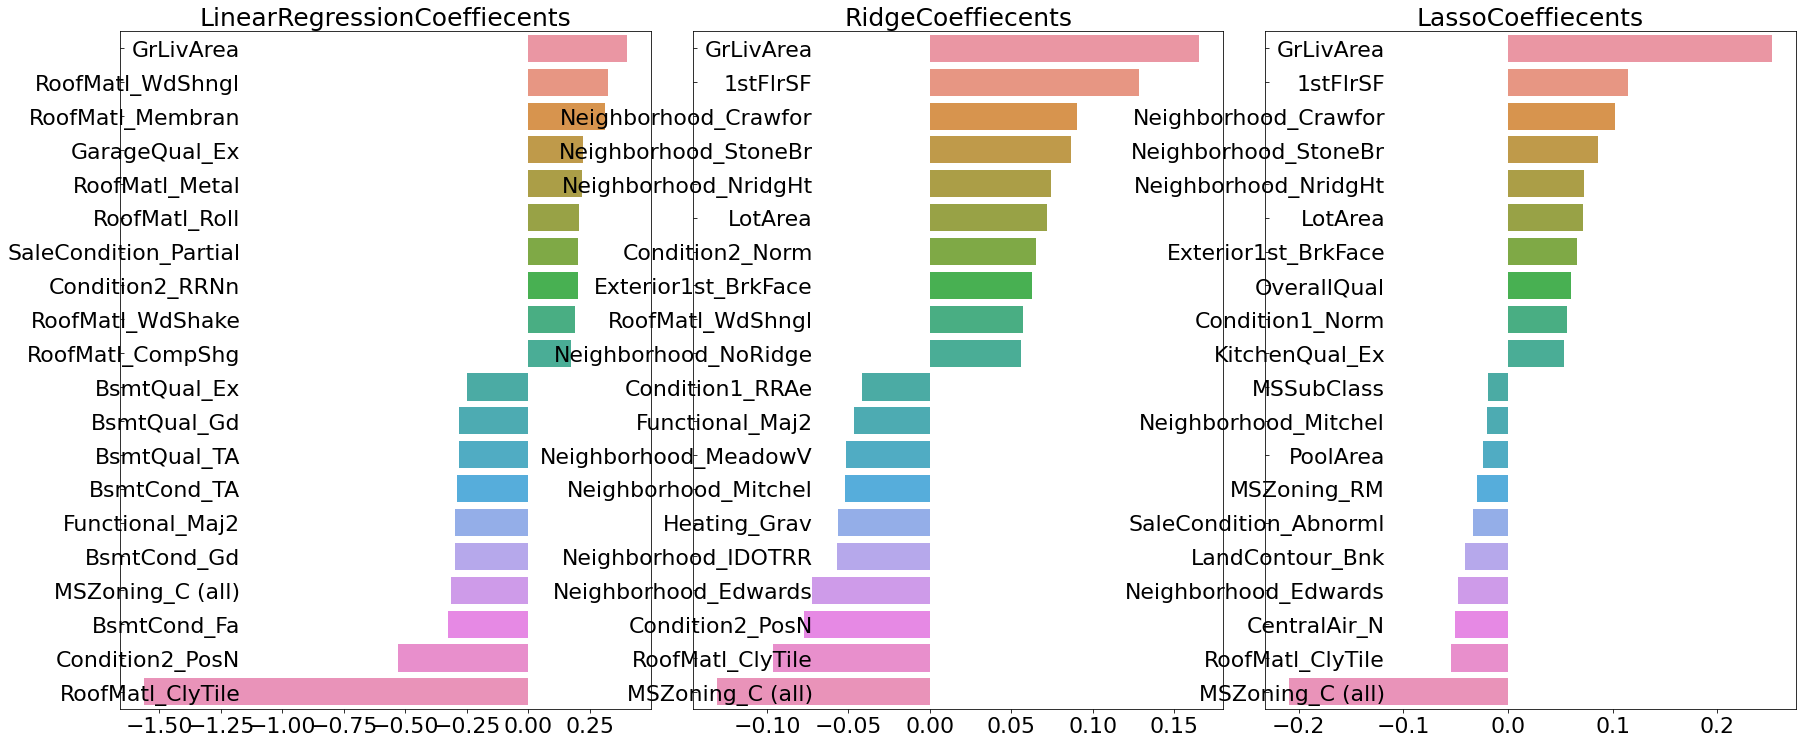

In [28]:
###다시 학습, 예측과 평가 진행

lr_reg = LinearRegression()
lr_reg.fit(x_train, y_train)
ridge_reg = Ridge(alpha=10)
ridge_reg.fit(x_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(x_train, y_train)

models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)
visualize_coefficient(models)

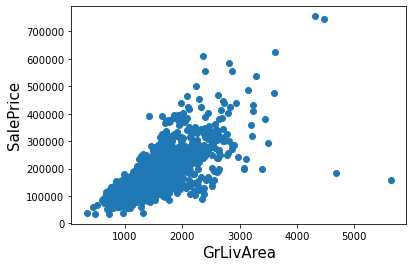

In [29]:
### GrLivArea(세 모델 모두에서 가장 큰 회귀 계수 가지는 피처)이상치 데이터 살펴보기

plt.scatter(x=house_df_org['GrLivArea'], y=house_df_org['SalePrice'])
plt.ylabel('SalePrice', fontsize=15)
plt.xlabel('GrLivArea', fontsize=15)
plt.show()
# 아래 2개의 데이터가 이상치 : 4000평방피트 이상임에도 가격이 낮은 것

In [30]:
### 이상치 데이터 제거

#로그 변환된 내용을 반영한 조건 생성
cond1 = house_df_ohe['GrLivArea'] > np.log1p(4000)
cond2 = house_df_ohe['SalePrice'] < np.log1p(500000)
outlier_index = house_df_ohe[cond1&cond2].index

print('이상치 레코드 인덱스 : ', outlier_index)
print('이상치 삭제 전 house_df_ohe.shape : ', house_df_ohe.shape)

house_df_ohe.drop(outlier_index, axis=0, inplace=True)
print('이상치 삭제 후 house_df_ohe.shape : ', house_df_ohe.shape)

이상치 레코드 인덱스 :  Int64Index([523, 1298], dtype='int64')
이상치 삭제 전 house_df_ohe.shape :  (1460, 271)
이상치 삭제 후 house_df_ohe.shape :  (1458, 271)


In [31]:
### 다시 데이터셋 설정하고 최적화, 결과 출력

y_target = house_df_ohe['SalePrice']
x_features = house_df_ohe.drop('SalePrice', axis=1, inplace=False)
x_train, x_test, y_train, y_test = train_test_split(x_features, y_target, test_size=0.2, random_state=156)

###다시 최적 하이퍼 파라미너와 RMSE 출력
ridge_params = {'alpha' : [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha' : [0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]}
print_best_params(ridge_reg, ridge_params) #12 -> 8이 됨
print_best_params(lasso_reg, lasso_params)
# 두 모델 모두 에측 수치 크게 향상

Ridge 5CV 시 최적 평균 RMSE 값 : 0.1125, 최적 alpha : {'alpha': 8}
Lasso 5CV 시 최적 평균 RMSE 값 : 0.1122, 최적 alpha : {'alpha': 0.001}


LinearRegression  로그 변환된 RMSE :  0.129
Ridge  로그 변환된 RMSE :  0.103
Lasso  로그 변환된 RMSE :  0.1


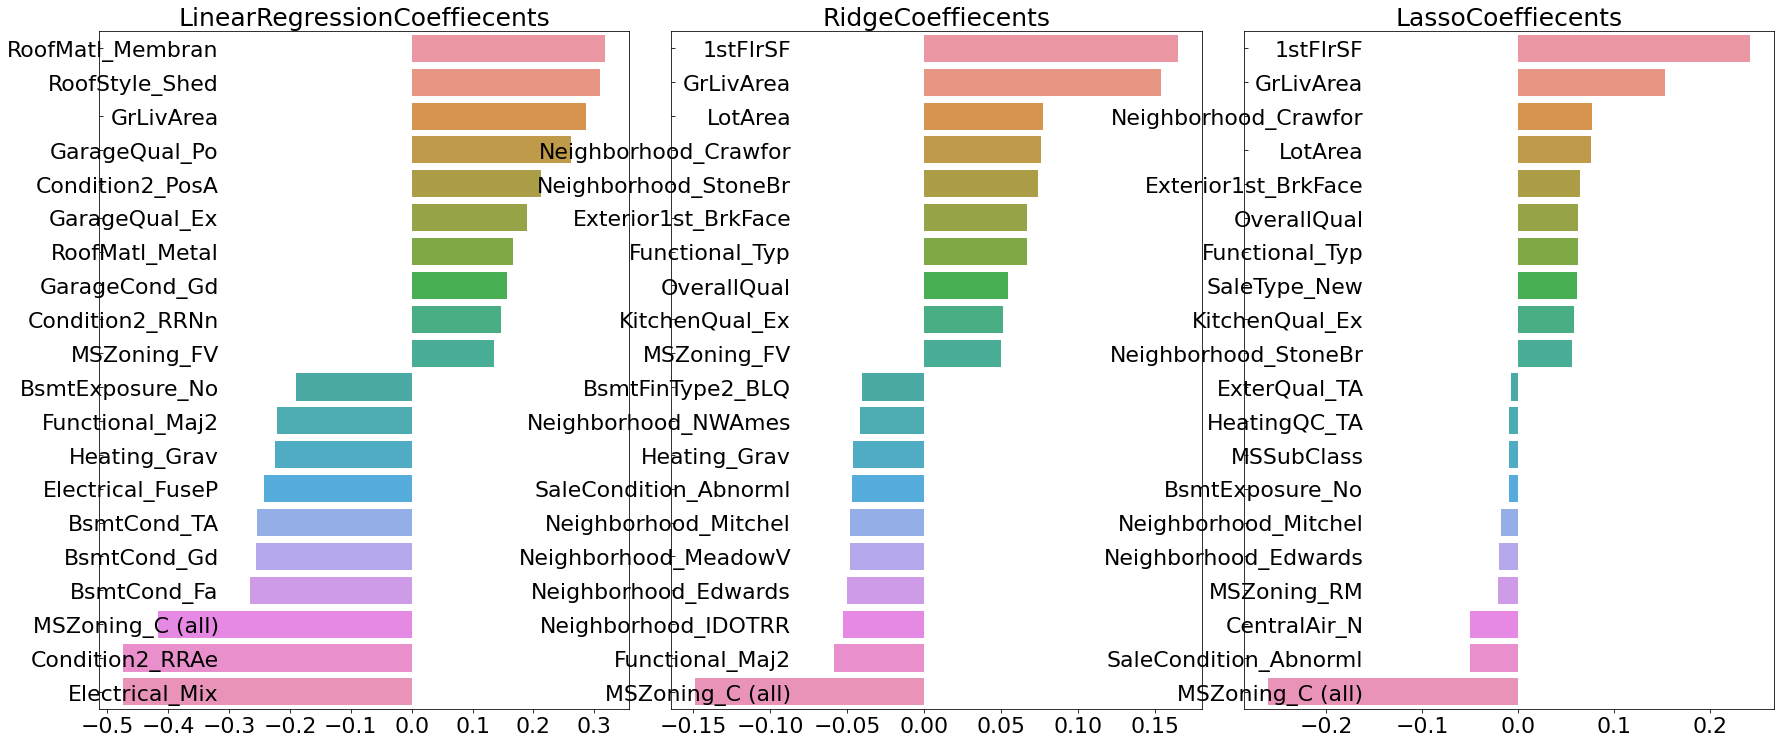

In [33]:
###다시 학습, 예측과 평가 진행

lr_reg = LinearRegression()
lr_reg.fit(x_train, y_train)
ridge_reg = Ridge(alpha=10)
ridge_reg.fit(x_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(x_train, y_train)

models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)
visualize_coefficient(models)

# 회귀 트리 모델 학습/예측/평가
* 수행시간이 오래 걸릴 수 있으므로, 하이퍼 파라미터 설정을 이미 한 뒤 5폴드 세트 평균 RMSE 구하기

In [34]:
xgb_params = {'n_estimators' : [1000]}
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05, colsample_bytree=0.5, subsample=0.8)
print_best_params(xgb_reg, xgb_params)

lgbm_params = {'n_estimators' : [1000]}
lgbm_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=4, subsample=0.6, colsample_bytree=0.4, reg_lambda=10, n_jobs=-1)
print_best_params(lgbm_reg, lgbm_params)

XGBRegressor 5CV 시 최적 평균 RMSE 값 : 0.1178, 최적 alpha : {'n_estimators': 1000}
LGBMRegressor 5CV 시 최적 평균 RMSE 값 : 0.1163, 최적 alpha : {'n_estimators': 1000}


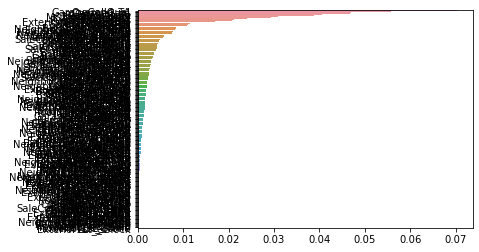

In [35]:
### 피처 중요도 시각화

xgb_reg.fit(x_train, y_train)
feature_series = pd.Series(data=xgb_reg.feature_importances_, index=x_train.columns)
feature_series = feature_series.sort_values(ascending=False)
sns.barplot(x=feature_series, y=feature_series.index)

# 회귀 모델의 예측 결과 혼합을 통한 최종 예측
* 개별 회귀 모델의 예측 결괏값을 혼합해 이를 기반으로 최종 회귀 값 예측하자
* 예측 결과 혼합의 예
  * A 모델의 예측값이 40%, B모델의 에측값이 60%를 더해 최종 회귓값으로 예측
  * A[100, 80, 60], B[120, 80, 50] 이라면 각 요소를 확률 곱해 [112, 80, 54]임

In [36]:
### 최종 혼합 모델, 개별 모델의 RMSE값을 출력하는 함수

def get_rmse_pred(preds):
    for key in preds.keys():
        pred_value = preds[key]
        mse = mean_squared_error(y_test, pred_value)
        rmse = np.sqrt(mse)
        print('{0} 모델의 RMSE : {1}'.format(key, rmse))

In [37]:
###릿지와 라쏘 모델의 혼합

#개별 모델의 학습
ridge_reg = Ridge(alpha=8)
ridge_reg.fit(x_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(x_train, y_train)

#개별 모델의 예측
ridge_pred = ridge_reg.predict(x_test)
lasso_pred = lasso_reg.predict(x_test)

#개별 모델 예측값 혼합으로 최종 예측값 도출
pred = 0.4*ridge_pred + 0.6*lasso_pred
preds = {'최종 혼합':pred, 'Ridge':ridge_pred, 'Lasso' : lasso_pred}

#최종 혼합 모델, 개별 모델의 RMSE 값 출력
get_rmse_pred(preds)

최종 혼합 모델의 RMSE : 0.10007930884470505
Ridge 모델의 RMSE : 0.10345177546603239
Lasso 모델의 RMSE : 0.1002417046089003


In [40]:
###XGBoost, LightGBM 모델의 혼합

#개별 모델의 학습
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05, colsample_bytree=0.5, subsample=0.8)
xgb_reg.fit(x_train, y_train)
lgbm_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=4, colsample_bytree=0.4, subsample=0.6, reg_lambda=10, n_jobs=-1)
lgbm_reg.fit(x_train, y_train)

#개별 모델의 예측
xgb_pred = xgb_reg.predict(x_test)
lgbm_pred = lgbm_reg.predict(x_test)

#개별 모델 예측값 혼합으로 최종 예측값 도출
pred = 0.5*xgb_pred + 0.5*lgbm_pred
preds = {'최종 혼합':pred, 'XGBM':xgb_pred, 'LGBM' : lgbm_pred}

#최종 혼합 모델, 개별 모델의 RMSE 값 출력
get_rmse_pred(preds)

최종 혼합 모델의 RMSE : 0.10170077353447762
XGBM 모델의 RMSE : 0.10738295638346222
LGBM 모델의 RMSE : 0.10382510019327311


# 스태킹 앙상블 모델을 통한 회귀 예측
* 4장 분류에서 소개한 스태킹 모델을 회귀에 적용 가능
* 스태킹 모델 구현 방법
  * 개별적 기반 모델 & 개별 기반 모델의 예측 데이터를 학습 데이터로 만들어 학습하는 최종 메타 모델 -> 이 2종류의 모델 필요
  * 여러 개별 모델의 예측 데이터를 각각 스태킹 형태로 결합 -> 최종 메타 모델의 학습용 리처 데이터셋과 테스트용 피처 데이터셋을 만듦
* 분류 뿐만 아니라 회귀에서도 스태킹은 효과적

In [46]:
### 개별 모델을 스태킹 모델로 제공하기 위해 데이터셋 생성하는 함수

def get_stacking_base_datasets(model, x_train_n, y_train_n, x_test_n, n_folds):
    #지정된 n_folds값으로 KFold 생성
    kf = KFold(n_splits=n_folds, shuffle=False, random_state=0)
    #추후 메타 모델이 사용할 학습 데이터 반환을 위한 넘파이 배열 초기화
    train_fold_pred = np.zeros((x_train_n.shape[0], 1))
    test_pred = np.zeros((x_test_n.shape[0], n_folds))
    print(model.__class__.__name__, ' model 시작')
    
    for folder_counter, (train_index, valid_index) in enumerate(kf.split(x_train_n)):
        #입력된 학습 데이터에서 기반 모델이 학습, 예측할 폴드 데이터 셋 추출
        print('\t폴드 세트 : ', folder_counter, ' 시작')
        x_tr = x_train_n[train_index]
        y_tr = y_train_n[train_index]
        x_te = x_train_n[valid_index]
        
        #폴드 세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습 수행
        model.fit(x_tr, y_tr)
        #폴드 세트 내부에서 다시 만들어진 검증 데이터로 기반 모델 예측 후 데이터 저장
        train_fold_pred[valid_index, :] = model.predict(x_te).reshape(-1, 1)
        #입력된 원본 테스트 데이터를 폴드 세트 내 학습된 기반 모델에서 예측 후 데이터 저장
        test_pred[:, folder_counter] = model.predict(x_test_n)
    
    #폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균해 테스트 데이터로 생성
    test_pred_mean = np.mean(test_pred, axis=1).reshape(-1, 1)
    
    #최종 메다 모델이 사용하는 학습 데이터, 테스트 데이터를 각각 반환
    return train_fold_pred, test_pred_mean

In [47]:
###모델별로 위 함수 적용 -> 메타 모델이 사용할 학습 피처 데이터셋/테스트 피처 데이터셋 추출

#위 함수는 넘파이 배열을 인자로 사용 -> dataframe을 넘파이로 변환
x_train_n = x_train.values
x_test_n = x_test.values
y_train_n = y_train.values

#각 개별 기반(base) 모델이 생성한 학습/테스트용 데이터 반환
ridge_train, ridge_test = get_stacking_base_datasets(ridge_reg, x_train_n, y_train_n, x_test_n, 5)
lasso_train, lasso_test = get_stacking_base_datasets(lasso_reg, x_train_n, y_train_n, x_test_n, 5)
xgb_train, xgb_test = get_stacking_base_datasets(xgb_reg, x_train_n, y_train_n, x_test_n, 5)
lgbm_train, lgbm_test = get_stacking_base_datasets(lgbm_reg, x_train_n, y_train_n, x_test_n, 5)

C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:293: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  warnings.warn(
C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:293: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  warnings.warn(


Ridge  model 시작
	폴드 세트 :  0  시작
	폴드 세트 :  1  시작
	폴드 세트 :  2  시작
	폴드 세트 :  3  시작
	폴드 세트 :  4  시작
Lasso  model 시작
	폴드 세트 :  0  시작
	폴드 세트 :  1  시작
	폴드 세트 :  2  시작
	폴드 세트 :  3  시작
	폴드 세트 :  4  시작


C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:293: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  warnings.warn(


XGBRegressor  model 시작
	폴드 세트 :  0  시작
	폴드 세트 :  1  시작
	폴드 세트 :  2  시작
	폴드 세트 :  3  시작
	폴드 세트 :  4  시작
LGBMRegressor  model 시작
	폴드 세트 :  0  시작
	폴드 세트 :  1  시작
	폴드 세트 :  2  시작
	폴드 세트 :  3  시작
	폴드 세트 :  4  시작


In [49]:
###최종 메타 모델에 적용

#개별 모델이 반환한 학습, 테스트용 데이터셋 스태킹 형태로 결합
Stack_final_x_train = np.concatenate((ridge_train, lasso_train, xgb_train, lgbm_train), axis=1)
Stack_final_x_test = np.concatenate((ridge_test, lasso_test, xgb_test, lgbm_test), axis=1)

#최종 메다 모델은 라쏘 적용
meta_model_lasso = Lasso(alpha=0.0005)

#개별 모델 예측값을 기반으로 새로 만들어진 학습/테이트 데이터로 메타 모델 예측 및 RMSE 측정
meta_model_lasso.fit(Stack_final_x_train, y_train)
final = meta_model_lasso.predict(Stack_final_x_test)
mse = mean_squared_error(y_test, final)
rmse = np.sqrt(mse)
print('스태킹 회귀 모델의 최종 RMSE : ', rmse) #현재까지 가장 좋은 성능 평가

스태킹 회귀 모델의 최종 RMSE :  0.09799152965189674
